In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
train_path = "/Users/JulioJerez/Desktop/Docs. Personales/Repositorio/PROYECTOS/store-sales-forecasting/data/raw/store-sales-time-series-forecasting/train.csv"
train = pd.read_csv(train_path, parse_dates=['date'])

In [49]:
train['year']=train['date'].dt.year
train['month']=train['date'].dt.month
train['day']=train['date'].dt.day
train['dow']=train['date'].dt.dayofweek ## 0=monday ... 6=sunday

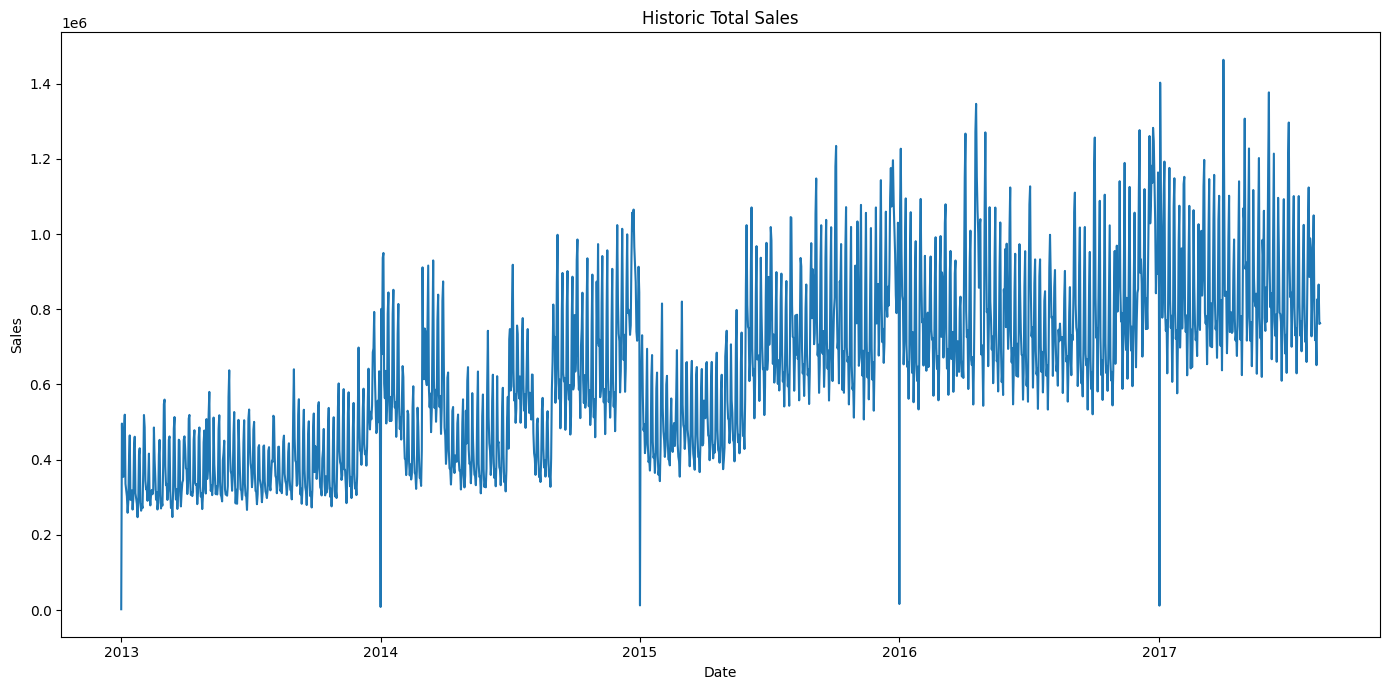

In [43]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(14,7))
plt.plot(daily_sales)
plt.title("Historic Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

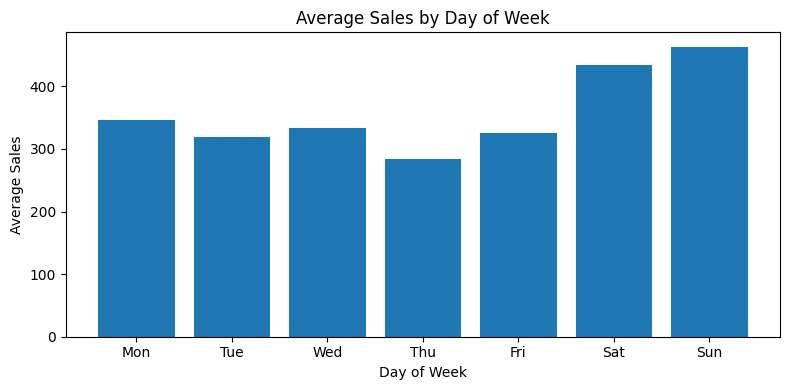

In [50]:
# 0=monday ... 6=sunday
dow_avg = train.groupby("dow")["sales"].mean()

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(8,4))
plt.bar(dow_labels, dow_avg.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

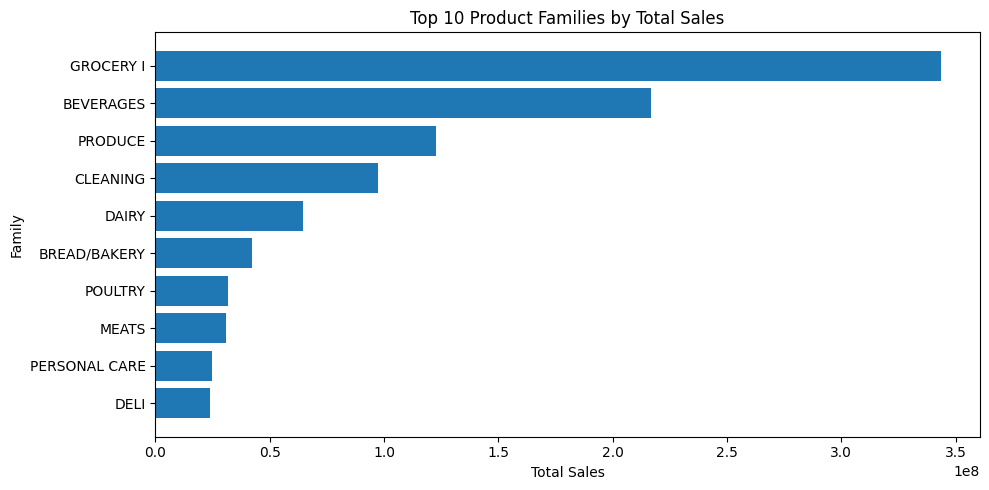

In [45]:
top10_families = (
    train.groupby("family")["sales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.barh(top10_families.index[::-1], top10_families.values[::-1])
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Family")
plt.tight_layout()
plt.show()

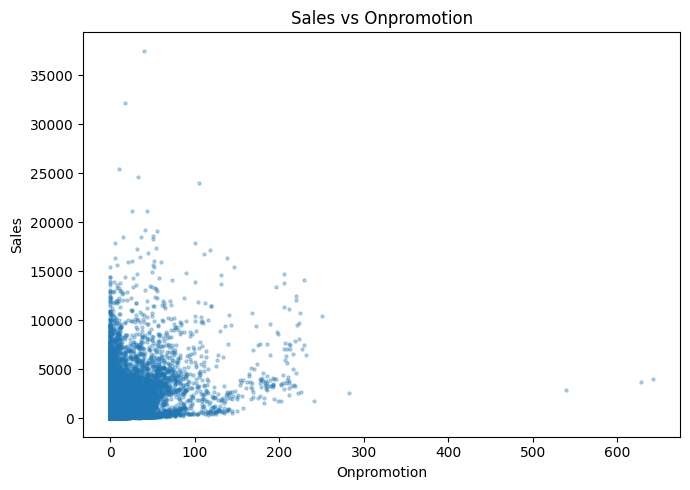

In [46]:
sample = train.sample(100_000, random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["onpromotion"], sample["sales"], s=5, alpha=0.3)
plt.title("Sales vs Onpromotion")
plt.xlabel("Onpromotion")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

/var/folders/kf/wqvl62316tgf28k5cfmtvj_h0000gn/T/ipykernel_12364/2701379908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sales_no_promo, sales_promo], labels=["No promo", "Promo"])


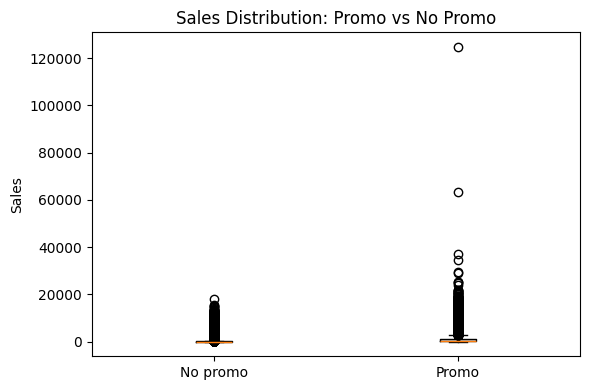

In [47]:
promo_flag = (train["onpromotion"] > 0)
sales_no_promo = train.loc[~promo_flag, "sales"].sample(100_000, random_state=42)
sales_promo    = train.loc[promo_flag,  "sales"].sample(100_000, random_state=42)

plt.figure(figsize=(6,4))
plt.boxplot([sales_no_promo, sales_promo], labels=["No promo", "Promo"])
plt.title("Sales Distribution: Promo vs No Promo")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()